# Restaurant Customer Analytics — Data Preprocessing

## Business Context

ChefMoz seeks to improve customer satisfaction and attract more customers by better understanding customer behavior, dining preferences, and factors influencing restaurant ratings.

This preprocessing notebook focuses on preparing the ChefMoz customer and restaurant datasets for downstream analysis by identifying and resolving data quality issues.

The cleaned dataset will support:

- Customer preference analysis
- Exploratory data analysis
- Feature engineering
- Customer satisfaction modelling
- Data-driven restaurant improvement recommendations

## Objective

The objective of this notebook is to transform raw ChefMoz data into a clean and reliable analytical dataset by:

- Inspecting dataset structure and quality
- Handling missing values
- Replacing inconsistent placeholder values
- Standardizing categorical variables
- Detecting and handling outliers
- Removing duplicate records
- Cleaning operational data formatting
- Exporting a processed dataset for feature engineering

In [95]:
# Import libraries
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

### 1. Load Dataset

In [96]:
df = pd.read_csv("../data/raw/chefmoz.csv")
df.head()

,userID,placeID,rating,food_rating,service_rating,latitude,longitude,smoker,drink_level,dress_preference,...,color,weight,budget,height,Rcuisine_x,Rcuisine_y,Rpayment,parking_lot,hours,days
0,U1077,135085,2,2,2,22.156469,-100.985540,false,social drinker,elegant,...,blue,65,medium,1.71,Mexican,Fast_Food,cash,public,00:00-00:00;,Mon;Tue;Wed;Thu;Fri;
1,U1077,135038,2,2,1,22.156469,-100.985540,false,social drinker,elegant,...,blue,65,medium,1.71,Mexican,NaN,cash,none,08:00-17:00;,Mon;Tue;Wed;Thu;Fri;
2,U1077,132825,2,2,2,22.156469,-100.985540,false,social drinker,elegant,...,blue,65,medium,1.71,Mexican,Mexican,cash,none,09:00-12:00;,Mon;Tue;Wed;Thu;Fri;
3,U1077,135060,1,2,2,22.156469,-100.985540,false,social drinker,elegant,...,blue,65,medium,1.71,Mexican,Seafood,cash,none,11:30-19:00;,Mon;Tue;Wed;Thu;Fri;
4,U1068,135104,1,1,2,23.752269,-99.168605,false,casual drinker,informal,...,blue,72,low,1.57,Mexican,Mexican,cash,yes,00:00-23:30;,Mon;Tue;Wed;Thu;Fri;


### 2. Basic Inspection
We check structure, datatypes, and potential data quality issues.

In [97]:
df.shape

(1161, 29)

In [98]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1161 entries, 0 to 1160
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   userID            1161 non-null   object 
 1   placeID           1161 non-null   int64  
 2   rating            1161 non-null   int64  
 3   food_rating       1161 non-null   int64  
 4   service_rating    1161 non-null   int64  
 5   latitude          1161 non-null   float64
 6   longitude         1161 non-null   float64
 7   smoker            1161 non-null   object 
 8   drink_level       1161 non-null   object 
 9   dress_preference  1161 non-null   object 
 10  ambience          1161 non-null   object 
 11  transport         1161 non-null   object 
 12  marital_status    1161 non-null   object 
 13  hijos             1161 non-null   object 
 14  birth_year        1161 non-null   int64  
 15  interest          1161 non-null   object 
 16  personality       1161 non-null   object 


,placeID,rating,food_rating,service_rating,latitude,longitude,birth_year,weight,height
count,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000
mean,134192.041344,1.199828,1.215332,1.090439,21.893060,-100.496817,1983.934539,63.241171,1.662842
std,1100.916275,0.773282,0.792294,0.790844,1.308759,0.788721,16.305780,16.221539,0.135386
min,132560.000000,0.000000,0.000000,0.000000,18.813348,-101.054680,1930.000000,40.000000,1.200000
25%,132856.000000,1.000000,1.000000,0.000000,22.138127,-100.984268,1987.000000,52.000000,1.600000
50%,135030.000000,1.000000,1.000000,1.000000,22.150891,-100.947888,1989.000000,64.000000,1.690000
75%,135059.000000,2.000000,2.000000,2.000000,22.177726,-99.250000,1991.000000,70.000000,1.750000
max,135109.000000,2.000000,2.000000,2.000000,23.771030,-99.067106,1994.000000,120.000000,2.000000


### 3. Inspect and handle missing values

In [99]:
df.isnull().sum().sort_values(ascending=False)

Rcuisine_y          288
Rpayment            100
days                  8
hours                 8
userID                0
latitude              0
longitude             0
smoker                0
drink_level           0
placeID               0
rating                0
food_rating           0
service_rating        0
marital_status        0
transport             0
ambience              0
dress_preference      0
hijos                 0
birth_year            0
interest              0
personality           0
weight                0
color                 0
activity              0
religion              0
Rcuisine_x            0
height                0
budget                0
parking_lot           0
dtype: int64

In [100]:
# Handling missing values
df["Rcuisine_y"] = df["Rcuisine_y"].fillna("unknown") # Handling Rcuisine_y missing values
df["Rpayment"] = df["Rpayment"].fillna("unknown")   # Handling Rpayment missing values
df["days"] = df["days"].fillna("not_specified")      # Handling days missing values
df["hours"] = df["hours"].fillna("not_specified")     # Handling hours missing values
# Verifying that there are no more missing values
df.isnull().sum().sort_values(ascending=False)


userID              0
placeID             0
rating              0
food_rating         0
service_rating      0
latitude            0
longitude           0
smoker              0
drink_level         0
dress_preference    0
ambience            0
transport           0
marital_status      0
hijos               0
birth_year          0
interest            0
personality         0
religion            0
activity            0
color               0
weight              0
budget              0
height              0
Rcuisine_x          0
Rcuisine_y          0
Rpayment            0
parking_lot         0
hours               0
days                0
dtype: int64

In [101]:
# Handling '?' values
df = df.replace("?", np.nan) # Replace '?' with NaN
# Apply mode only to marital_status
df["marital_status"] = df["marital_status"].fillna(df["marital_status"].mode()[0])

cols = ["hijos", "ambience", "transport", "activity"]
df[cols] = df[cols].fillna("Unknown")

# Check remaining missing values
print(df.isnull().sum().sort_values(ascending=False))


budget              69
dress_preference    51
smoker              31
placeID              0
rating               0
service_rating       0
food_rating          0
longitude            0
latitude             0
drink_level          0
ambience             0
transport            0
userID               0
marital_status       0
hijos                0
interest             0
birth_year           0
religion             0
activity             0
color                0
personality          0
weight               0
height               0
Rcuisine_x           0
Rcuisine_y           0
Rpayment             0
parking_lot          0
hours                0
days                 0
dtype: int64


### 4. Standardize Categorical Variables

In [102]:
# Standardize column names
df.columns = df.columns.str.lower().str.strip()

# Verify updated column names
print(df.columns)

# Identifying categorical columns
cat_cols = df.select_dtypes(include="object").columns

cat_cols = [col for col in cat_cols if col not in ["userID", "placeID"]]
# Standardizing categorical columns by converting to lowercase and stripping whitespace
for col in cat_cols:
    df[col] = df[col].str.lower().str.strip()

# Verifying that the standardization worked correctly
for col in cat_cols:
    print(f"Checking: {col}")
    
    has_upper = df[col].dropna().str.contains(r'[A-Z]', regex=True).any()
    has_spaces = (
        df[col].dropna().str.startswith(' ').any() or
        df[col].dropna().str.endswith(' ').any()
    )
    
    print(f"Contains uppercase: {has_upper}")
    print(f"Contains extra spaces: {has_spaces}")

Index(['userid', 'placeid', 'rating', 'food_rating', 'service_rating',
       'latitude', 'longitude', 'smoker', 'drink_level', 'dress_preference',
       'ambience', 'transport', 'marital_status', 'hijos', 'birth_year',
       'interest', 'personality', 'religion', 'activity', 'color', 'weight',
       'budget', 'height', 'rcuisine_x', 'rcuisine_y', 'rpayment',
       'parking_lot', 'hours', 'days'],
      dtype='object')


Checking: userid
Contains uppercase: False
Contains extra spaces: False
Checking: smoker
Contains uppercase: False
Contains extra spaces: False
Checking: drink_level
Contains uppercase: False
Contains extra spaces: False
Checking: dress_preference
Contains uppercase: False
Contains extra spaces: False
Checking: ambience
Contains uppercase: False
Contains extra spaces: False
Checking: transport
Contains uppercase: False
Contains extra spaces: False
Checking: marital_status
Contains uppercase: False
Contains extra spaces: False
Checking: hijos
Contains uppercase: False
Contains extra spaces: False
Checking: interest
Contains uppercase: False
Contains extra spaces: False
Checking: personality
Contains uppercase: False
Contains extra spaces: False
Checking: religion
Contains uppercase: False
Contains extra spaces: False
Checking: activity
Contains uppercase: False
Contains extra spaces: False
Checking: color
Contains uppercase: False
Contains extra spaces: False
Checking: budget
Contains u

In [103]:
print(df["days"].unique()[:20])

['mon;tue;wed;thu;fri;' 'not_specified' 'sat;']


In [104]:
# Standardizing 'days' column by replacing ';' with ', '
df["days"] = df["days"].str.replace(";", ", ", regex=False)
print(df["days"].unique()[:20])

['mon, tue, wed, thu, fri, ' 'not_specified' 'sat, ']


### 5. Check for duplicates

In [117]:
# Check duplicates
print(df.duplicated().sum())

0


### 6. Outlier Detection

In [105]:
# Inspect numerical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
print(num_cols)

Index(['placeid', 'rating', 'food_rating', 'service_rating', 'latitude',
       'longitude', 'birth_year', 'weight', 'height'],
      dtype='object')


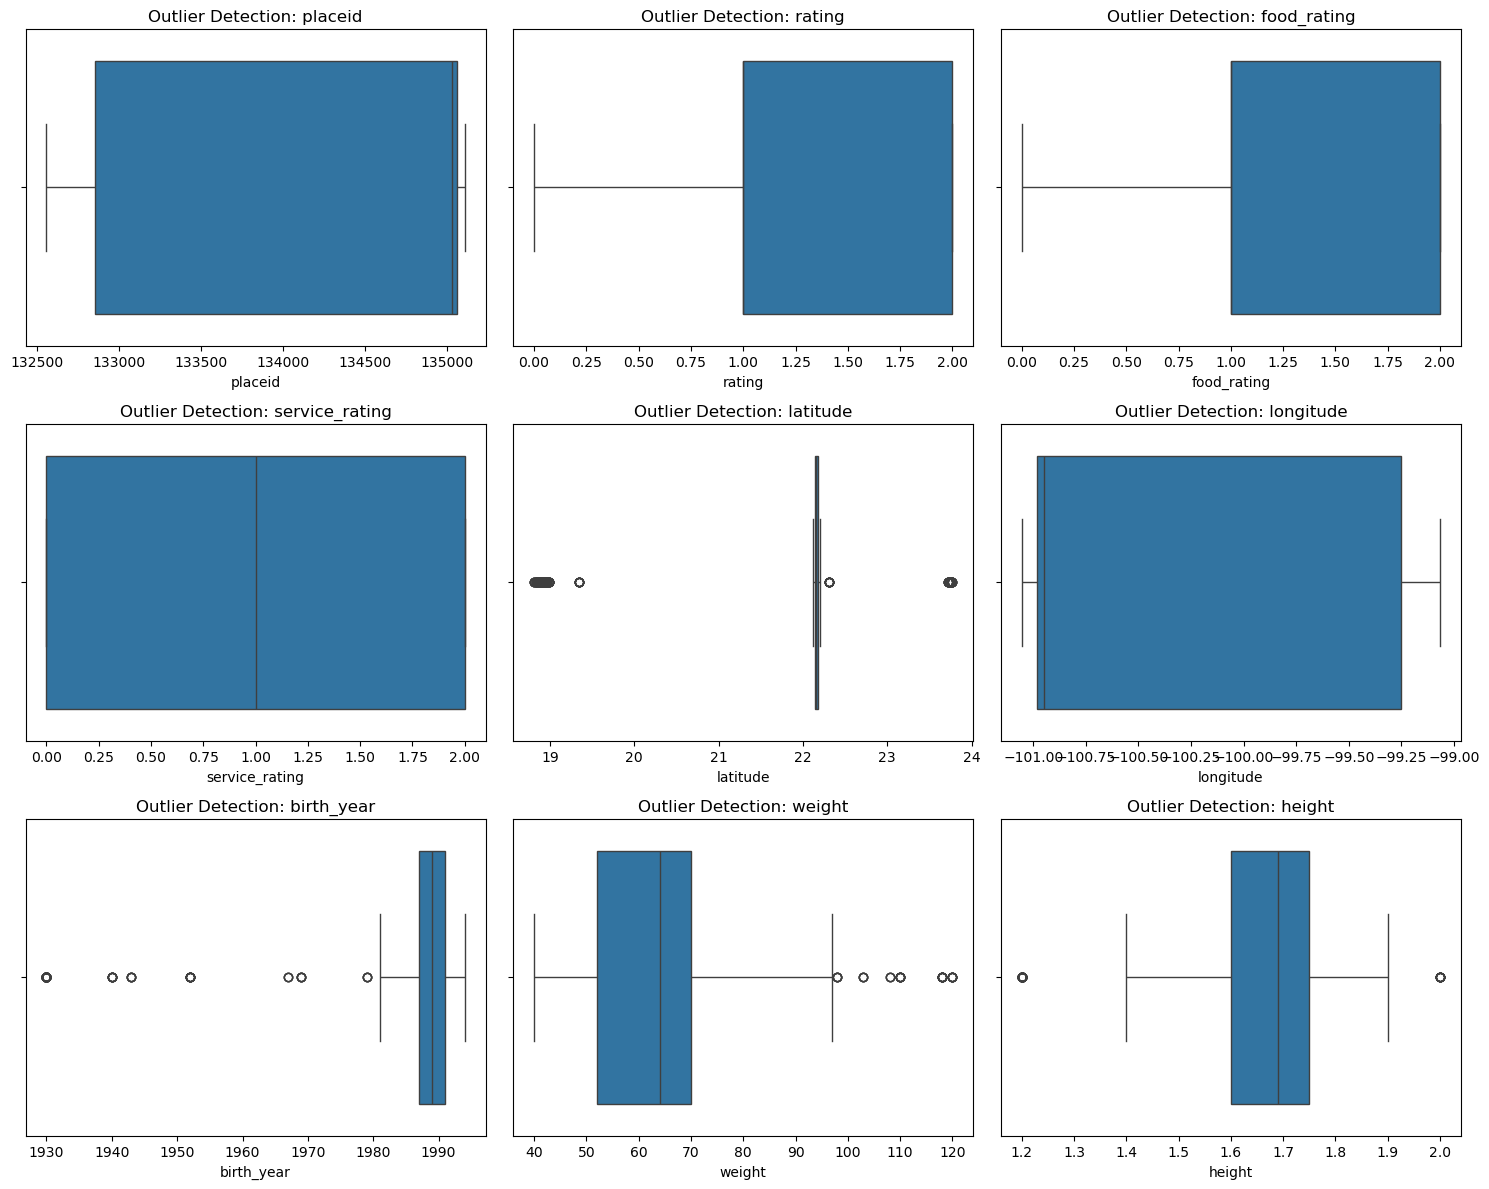

In [106]:
# Define subplot layout
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols   # avoids using math.ceil()

# Create figure and axes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

# Flatten axes array
axes = axes.flatten()

# Plot boxplots
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Outlier Detection: {col}')

# Remove empty subplots
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- Most variables have fairly consistent distributions with few extreme values.
- `rating`, `food_rating`, and `service_rating` show no meaningful outliers due to their small scale.
- `latitude` contains a few noticeable outliers, while `longitude` is relatively stable.
- `birth_year`, `weight`, and `height` show several outliers that may represent extreme but realistic values.
- `placeID` acts as an identifier, making outlier detection less relevant.

In [107]:
# Removing outliers from 'latitude' column using IQR method
Q1 = df['latitude'].quantile(0.25)
Q3 = df['latitude'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['latitude'] >= lower) & (df['latitude'] <= upper)]

In [108]:
# Removing outliers from 'birth_year' column using quantile method
lower = df['birth_year'].quantile(0.01)
upper = df['birth_year'].quantile(0.99)

df['birth_year'] = df['birth_year'].clip(lower, upper)

In [109]:
# Removing outliers from 'weight' column using IQR method
Q1 = df['weight'].quantile(0.25)
Q3 = df['weight'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['weight'] = df['weight'].clip(lower, upper)

In [110]:
# Removing outliers from 'weight' column using IQR method
Q1 = df['height'].quantile(0.25)
Q3 = df['height'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['height'] = df['height'].clip(lower, upper)

### 6. Inspect Unique Values

In [111]:
for col in cat_cols:
    print(f"\n {col}")
    print(df[col].value_counts().to_string())


 userid
userid
u1061    18
u1134    16
u1024    15
u1022    14
u1135    14
u1137    14
u1089    14
u1071    13
u1016    13
u1112    13
u1053    13
u1003    13
u1097    13
u1036    12
u1098    12
u1122    12
u1104    12
u1088    12
u1075    12
u1116    11
u1125    11
u1096    11
u1027    11
u1033    11
u1006    11
u1057    11
u1025    11
u1073    11
u1037    11
u1099    11
u1054    11
u1128    11
u1111    11
u1114    11
u1081    11
u1009    11
u1124    10
u1085    10
u1090    10
u1136    10
u1058    10
u1002    10
u1032    10
u1029    10
u1056    10
u1108    10
u1126    10
u1018    10
u1055    10
u1045    10
u1084    10
u1132    10
u1101    10
u1013    10
u1095    10
u1091     9
u1086     9
u1008     9
u1083     9
u1001     9
u1120     9
u1046     9
u1049     9
u1019     9
u1062     9
u1005     9
u1007     9
u1015     8
u1105     8
u1113     8
u1115     8
u1010     8
u1078     7
u1048     7
u1092     6
u1034     6
u1131     6
u1076     5
u1064     5
u1077     5
u1038     5
u1102     5


In [112]:
print(df["hijos"].value_counts())

hijos
independent    683
unknown         77
kids            71
dependent       16
Name: count, dtype: int64


## Final Validation

In [113]:
df. columns

Index(['userid', 'placeid', 'rating', 'food_rating', 'service_rating',
       'latitude', 'longitude', 'smoker', 'drink_level', 'dress_preference',
       'ambience', 'transport', 'marital_status', 'hijos', 'birth_year',
       'interest', 'personality', 'religion', 'activity', 'color', 'weight',
       'budget', 'height', 'rcuisine_x', 'rcuisine_y', 'rpayment',
       'parking_lot', 'hours', 'days'],
      dtype='object')

In [114]:
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 847 entries, 0 to 1111
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   userid            847 non-null    object 
 1   placeid           847 non-null    int64  
 2   rating            847 non-null    int64  
 3   food_rating       847 non-null    int64  
 4   service_rating    847 non-null    int64  
 5   latitude          847 non-null    float64
 6   longitude         847 non-null    float64
 7   smoker            820 non-null    object 
 8   drink_level       847 non-null    object 
 9   dress_preference  811 non-null    object 
 10  ambience          847 non-null    object 
 11  transport         847 non-null    object 
 12  marital_status    847 non-null    object 
 13  hijos             847 non-null    object 
 14  birth_year        847 non-null    int64  
 15  interest          847 non-null    object 
 16  personality       847 non-null    object 
 17  r

## Save Clean Dataset

In [115]:
df.to_csv("../data/processed/chefmoz_clean.csv", index=False)
df.head()

,userid,placeid,rating,food_rating,service_rating,latitude,longitude,smoker,drink_level,dress_preference,...,color,weight,budget,height,rcuisine_x,rcuisine_y,rpayment,parking_lot,hours,days
0,u1077,135085,2,2,2,22.156469,-100.985540,false,social drinker,elegant,...,blue,65.0,medium,1.71,mexican,fast_food,cash,public,00:00-00:00;,"mon, tue, wed, thu, fri,"
1,u1077,135038,2,2,1,22.156469,-100.985540,false,social drinker,elegant,...,blue,65.0,medium,1.71,mexican,unknown,cash,none,08:00-17:00;,"mon, tue, wed, thu, fri,"
2,u1077,132825,2,2,2,22.156469,-100.985540,false,social drinker,elegant,...,blue,65.0,medium,1.71,mexican,mexican,cash,none,09:00-12:00;,"mon, tue, wed, thu, fri,"
3,u1077,135060,1,2,2,22.156469,-100.985540,false,social drinker,elegant,...,blue,65.0,medium,1.71,mexican,seafood,cash,none,11:30-19:00;,"mon, tue, wed, thu, fri,"
47,u1015,135071,0,0,0,22.126760,-100.905209,true,social drinker,informal,...,black,87.0,medium,1.67,mexican,bar,cash,yes,13:00-23:30;,"mon, tue, wed, thu, fri,"
